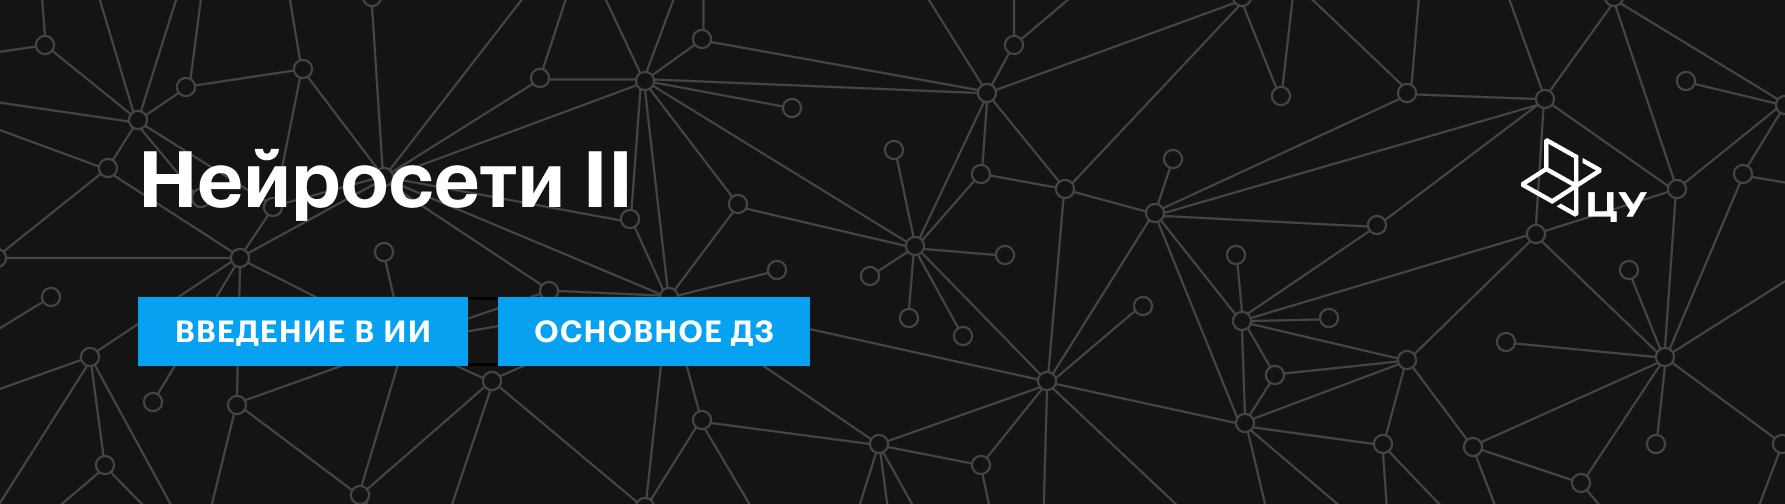

# Домашнее задание по теме «Нейросети II»

Сегодня ты продолжишь решать задачу классификации рукописных цифр MNIST c помощью нейросети и потренируешься:


*   вычислять метрику на этапе валидации;
*   нормализовать данные при подготовке датасета;
*   использовать слой BatchNorm;
*   применять шедулер.

> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.


## Задание 1 [3 балла]

На семинаре мы вычисляли `loss` при валидации нейросети. Это корректно: по значению функции потерь можно отслеживать, как модель обучается.

Однако `loss` не всегда понятен бизнесу как показатель качества решения задачи. Для этого используют метрики.

Проблема в том, что многие метрики нельзя оптимизировать напрямую. Но если важно оценивать качество алгоритма именно по выбранной метрике, её можно вычислять на этапе валидации.

Это тебе и предстоит сделать.
1. Добавь вычисление метрики `Accuracy` из sklearn после валидации на эпохе (подробности в коде) **[1 балл]**.
2. Добавь в `print` лог, который выводит значение `Accuracy` на валидации **[0,5 балла]**.
3. Обучи модель с семинара с реализованным вычислением `Accuracy`. Скачай веса лучшей модели и прикрепи их к домашнему заданию **[0,5 балла]**.
4. Опиши, что получилось. Сравни `loss` и `Accuracy` на валидации: всегда ли модель с минимальным `loss` даёт лучшую метрику? **[1 балл]**.

> **Важно**. Запомни результат на валидации. Дальше ты будешь усложнять модель, и это может повлиять на качество решения.



> **Подсказка.** Следующие 10 ячеек содержат код с семинара, просто запусти их.



In [94]:
# Импортируем нужные пакеты
import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import MNIST

from tqdm import tqdm

In [95]:
# Загружаем датасет
train_ = MNIST('/content', # Папка для сохранения или загрузки
              download=True, # Если нет в папке, нужно скачать из интернета
              train=True) # train-подвыборка
test = MNIST('/content', download=True, train=False)

# Извлекаем данные из датасета
X_train, y_train = train_.data, train_.targets
X_test, y_test = test.data, test.targets

In [96]:
# Определяем класс датасета
class DatasetMNIST(Dataset):

  def __init__(self, X, y):
    self.X = X.flatten(start_dim=1) / 255
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [97]:
# Создаём датасеты
train_ds = DatasetMNIST(X_train, y_train)
test_ds = DatasetMNIST(X_test, y_test)

In [98]:
# Определяем DataLoader
train_dl = DataLoader(
    train_ds, # Наш датасет
    batch_size=64, # Размер батча. Меньше 32 согласно многим исследованиям ставить не рекоммендуется из-за потерь в качестве
    shuffle=True, # Указываем, перемешивать ли данные перед каждой эпохой (проходом по данным). Для train-подвыборки всегда ставим True, кроме единичных исключений
    drop_last=True, # Если последний батч неполный, не используем его для обучения
    num_workers=1, # Число процессов для загрузки данных (обычно выбирают по числу ядер CPU)
    persistent_workers=True # Используем, чтобы не создавать каждый раз новый процесс при обращении к DataLoader. Полезно для небольшого ускорения исполнения
)

test_dl = DataLoader(
    test_ds, # Тестовый датасет
    batch_size=64*4, # Можно увеличить, так как обучение не выполняется: при получении предсказаний требуется меньше ресурсов, поэтому в GPU помещается батч большего размера
    shuffle=False, # Не будем перемешивать
    drop_last=False, # И исключать неполный батч тоже не будем, потому что нужны предсказания для него
    num_workers=1,
    persistent_workers=True
)

In [99]:
# Функция для одного шага обучения
def train_step(batch, model, loss, optimizer, device):

    model.zero_grad()

    X, y = batch
    X = X.to(device)
    y = y.to(device)

    logits = model(X)
    l = loss(logits, y)

    l.backward()
    optimizer.step()

    return l.item()

In [100]:
# Функция для обучения на эпохе
def train(model, loss, optimizer, device, train_dataloader):
    model.train()
    train_loss = 0

    for batch in tqdm(train_dataloader):
      loss_step = train_step(batch, model, loss, optimizer, device)
      train_loss += loss_step / len(train_dataloader)

    return train_loss

In [101]:
# Функция для одного шага валидации
def valid_step(batch, model, loss, device):

      X, y = batch
      X = X.to(device)
      y = y.to(device)

      with torch.no_grad():
        logits = model(X)
        l = loss(logits, y)

      return logits.argmax(dim=-1).detach().cpu().numpy(), l.item()

In [102]:
# Функция для всей валидации на эпохе, будем использовать её также для получения предсказаний
def validate(model, loss, device, val_dataloader):
  model.eval()
  val_loss = 0
  preds = []
  for batch in tqdm(val_dataloader):
    preds_step, loss_step = valid_step(batch, model, loss, device)

    val_loss += loss_step / len(val_dataloader)
    preds.append(preds_step)

  preds = np.concatenate(preds)

  return preds, val_loss

Добавь в функцию `train_and_validate`:
  * вычисление `Accuracy` после валидации;
  * вывод значения `Accuracy` в лог.

Допиши представленные ниже функции.

In [103]:
# Для начала сделаем импорт нужной функции из sklearn
from sklearn.metrics import accuracy_score

In [104]:
def train_and_validate(epochs, model, loss, optimizer, device, train_dataloader, val_dataloader, save_every=1, naming=''):

    model.to(device)

    for e in range(epochs):

        train_loss = train(model, loss, optimizer, device, train_dataloader)
        val_preds, val_loss = validate(model, loss, device, val_dataloader)

        y = []
        for batch in val_dataloader:
            y.append(batch[1])
        y = np.concatenate(y)

        valid_acc = accuracy_score(y, val_preds)# Напиши код здесь

        print(f'Эпоха: {e} | Train Loss {train_loss} | Val Loss {val_loss} | Valid Acc {valid_acc}') # Добавь в print полученное значение с соответствующей подписью

        if e % save_every == 0:
            torch.save(model.state_dict(), f'model_epoch_{e}{naming}.pth')

In [105]:
# Определяем модель с семинара — её менять не нужно
class FCMNIST(nn.Module):

  def __init__(self):
    super().__init__() # Не забываем super init сделать, без этого ничего работать не будет

    # Линейный слой —> ReLU —> Линейный слой —> и так далее
    self.net = nn.Sequential(
        nn.Linear(784, 392),
        nn.ReLU(),
        nn.Linear(392, 191),
        nn.ReLU(),
        nn.Linear(191, 80),
        nn.ReLU(),
        nn.Linear(80, 40),
        nn.ReLU(),
        nn.Linear(40, 10)
    )

  def forward(self, X):
    return self.net(X)

In [106]:
# Инициализируем модель
model = FCMNIST()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
loss = nn.CrossEntropyLoss() # Кросс-энтропия, самая популярная функция потерь для решения задачи классификации. Разбиралась на лекциях
epochs = 10# Выбери количество эпох
device = "cuda" if torch.cuda.is_available() else "cpu"# Напиши логическое выражение, которое определяет девайс: GPU или CPU. Если хочешь считать на GPU, включи его в «Среде выполнения»

In [107]:
# Запусти
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl)

100%|██████████| 40/40 [00:00<00:00, 110.03it/s]


Эпоха: 0 | Train Loss 0.8996987364303592 | Val Loss 0.19436986832879485 | Valid Acc 0.9397


100%|██████████| 40/40 [00:00<00:00, 109.77it/s]


Эпоха: 1 | Train Loss 0.1637268370552149 | Val Loss 0.11288134922506292 | Valid Acc 0.9655


100%|██████████| 40/40 [00:00<00:00, 115.74it/s]


...

Эпоха: 7 | Train Loss 0.027243985623961655 | Val Loss 0.07224728998799035 | Valid Acc 0.9809


100%|██████████| 40/40 [00:00<00:00, 63.15it/s]


Эпоха: 8 | Train Loss 0.02097243876365415 | Val Loss 0.11454562388207705 | Valid Acc 0.9718


100%|██████████| 40/40 [00:00<00:00, 120.73it/s]


Эпоха: 9 | Train Loss 0.01586037411158739 | Val Loss 0.09021105669216918 | Valid Acc 0.9776


In [108]:
model.load_state_dict(torch.load('/content/model_epoch_8.pth'))

<All keys matched successfully>



> **Важно.** Не забудь скачать веса лучшей модели.



Какие результаты у тебя получились? Является ли модель с минимальным `loss` также лучшей по метрике?

Обе лучшие на 8 эпохе, но как будто не обязательно


## Задание 2 [4 балла]

> **Нормализация** — это стандартизация данных: из каждого значения вычитают среднее по выборке и делят на стандартное отклонение:

$$X_{norm} = \frac{X - \mu}{\sigma}.$$

Важно учитывать, что мы работаем с изображениями. Обычно изображения нормализуют по каналам (RGB — Red, Green, Blue), то есть для каждого канала отдельно.

В датасете MNIST изображения чёрно-белые, поэтому канал только один. Значит, нужно вычислить всего одно значение среднего и стандартного отклонения, а не 784 значения, как для табличных данных.

**Выполни нормализацию входных данных.**

1. Модифицируй класс датасета так, чтобы он нормализовал данные для обучения и выводил среднее и стандартное отклонение train-подвыборки **[2 балла]**.
2.  Инициализируй класс с полученными статистиками для валидационной подвыборки **[1 балл]**.
3. Обучи нейросеть и выведи все логи **[0,5 балла]**.
4. Опиши результат. Стало ли лучше? **[0,5 балла]**.



In [109]:
# Определяем класс датасета
class DatasetMNIST(Dataset):

  def __init__(self, X, y, mean=None, std=None): # Теперь передаём статистики в датасет

    # Данный блок не меняем
    self.X = X.flatten(1) / 255
    self.y = y

    # Если нет среднего или стандартного отклонения
    if not mean or not std:
      self.mean = self.X.mean()
      self.std = self.X.std()# Посчитай стандартное отклонение
      print(self.mean, self.std) # Выводим значения на экран
    else:
      self.mean = mean
      self.std = std
    self.X = (self.X - self.mean) / self.std# Нормализуем данные

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [110]:
# Пересоздаём датасеты и DataLoader
# Создаём обучающий датасет
train_ds = DatasetMNIST(X_train, y_train)

tensor(0.1307) tensor(0.3081)


In [111]:
# Передаём вычисленные статистики в валидационный датасет
test_ds = DatasetMNIST(X_test, y_test, train_ds.mean, train_ds.std) # Передай сюда полученные статистики

In [112]:
train_dl = DataLoader(
    train_ds, # Наш датасет
    batch_size=64, # Размер батча. Меньше 32 согласно многим исследованиям ставить не рекомендуется из-за потерь в качестве
    shuffle=True, # Указываем, перемешивать ли данные перед каждой эпохой (проходом по данным). Для train-подвыборки всегда ставим True, кроме единичных исключений
    drop_last=True, # Если последний батч будет неполным, то не обучаемся на нём
    num_workers=1, # Число процессов для загрузки данных (обычно выбирают по числу ядер CPU)
    persistent_workers=True # Указываем, чтобы не создавать каждый раз новый процесс при обращении к DataLoader. Полезно для небольшого ускорения исполнения
)

test_dl = DataLoader(
    test_ds, # Тестовый датасет
    batch_size=64*4, # Можно увеличить, так как обучение не выполняется: при получении предсказаний требуется меньше ресурсов, поэтому в GPU помещается батч большего размера
    shuffle=False, # Не будем перемешивать
    drop_last=False, # И исключать неполный батч тоже не будем, потому что нужны предсказания для него
    num_workers=1,
    persistent_workers=True
)

In [113]:
# Инициализируем модель
model = FCMNIST()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
loss = nn.CrossEntropyLoss() # Кросс-энтропия, самая популярная функция потерь для решения задачи классификации. Разбиралась на лекциях
epochs = 10# Количество эпох
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [114]:
# Запускаем обучение
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl, naming='_norm') # Добавляем суффикс к имени файла, чтобы различать сохранённые веса

100%|██████████| 40/40 [00:00<00:00, 93.31it/s]


Эпоха: 0 | Train Loss 0.4589418982758944 | Val Loss 0.1298257083632052 | Valid Acc 0.9599


100%|██████████| 40/40 [00:00<00:00, 120.95it/s]


Эпоха: 1 | Train Loss 0.11053178830046442 | Val Loss 0.09899779544211924 | Valid Acc 0.9676


100%|██████████| 40/40 [00:00<00:00, 110.25it/s]


...

Эпоха: 7 | Train Loss 0.015194925219690885 | Val Loss 0.09015142703689208 | Valid Acc 0.9775


100%|██████████| 40/40 [00:00<00:00, 108.03it/s]


Эпоха: 8 | Train Loss 0.015710241719081756 | Val Loss 0.07772279540549787 | Valid Acc 0.9795


100%|██████████| 40/40 [00:00<00:00, 103.87it/s]


Эпоха: 9 | Train Loss 0.010825519056815969 | Val Loss 0.08141567398250515 | Valid Acc 0.9804


>**Важно.** Не забудь сохранить веса лучшей модели на валидации.

In [115]:
model.load_state_dict(torch.load('/content/model_epoch_8_norm.pth'))

<All keys matched successfully>

Удалось ли улучшить качество? Напиши выводы здесь.

да, лосс стал ниже стабильнее. тут кстати как раз лосс меньший на 3 эпохе, а лчший accuracy на 8 эпохе, то есть опровергается гипотеза из 1 пункта

## Задание 3 [3 балла]

Мы нормализуем только входные данные. Однако после каждого слоя нейросети формируется новое представление данных, которое может иметь произвольное распределение. Поэтому в нейросетях часто используют слой [BatchNorm](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html).

Он нормализует наши данные аналогично тому, как мы нормализовали входные данные. Зачем BatchNorm тогда нужен? Мы производим обучение по батчам. Удобно считать необходимые для нормализации среднее арифметическое и отклонение не по всей выборке, а у каждого батча, постепенно накапливая эти значения. Именно этим занимается BatchNorm!

Также у этого слоя есть обучаемые параметры — коэффициент масштабирования и сдвиг. Они помогают изменить эффект нормализации, умножив данные на коэффициент и добавив смещение.



**Поработай над архитектурой нейросети, добавив BatchNorm между слоями.**

1. Модифицируй нейросеть, добавив BatchNorm **[1 балл]**.

*   Слой BatchNorm можно ставить как до, так и после функции активации. Можешь попробовать разные варианты и посмотреть, какой будет лучше!
*   
   Этот слой принимает на вход один аргумент — размер входных данных. Поэтому, если на вход BatchNorm подаётся вектор длиной 100, надо инициализировать её через `nn.BatchNorm1d(100)`.
 2. Обучи все и сохрани лучшую модель **[1 балла]**.

 3. Опиши, что получилось **[1 балла]**.

 >**Важно:** BatchNorm бывает разных типов. В этой задаче используй слой [BatchNorm1d](https://www.google.com/url?q=https%3A%2F%2Fpytorch.org%2Fdocs%2Fstable%2Fgenerated%2Ftorch.nn.BatchNorm1d.html).



In [116]:
class NormFCMNIST(nn.Module): # Norm добавлено в название, чтобы различать классы

  def __init__(self):
    super().__init__() # Не забываем super init сделать, без этого ничего работать не будет
    # Не надо вставлять BatchNorm до и после активации. Выбери одно расположение
    # Линейный слой —> (?Batchnorm) —> ReLU —> (?Batchnorm) —> Линейный слой —> и так далее
    self.net = nn.Sequential(
        nn.Linear(784, 392),
        nn.BatchNorm1d(392),
        nn.ReLU(),

        nn.Linear(392, 191),
        nn.BatchNorm1d(191),
        nn.ReLU(),

        nn.Linear(191, 80),
        nn.BatchNorm1d(80),
        nn.ReLU(),

        nn.Linear(80, 40),
        nn.BatchNorm1d(40),
        nn.ReLU(),

        nn.Linear(40, 10)
    )

  def forward(self, X):
    return self.net(X)

Объясни, куда был добавлен BatchNorm и почему?




добавил между подсчетом линейного слоя и релу, чтобы нормализовать количество и релу убирало стабильное колво аргументов

In [117]:
# Инициализируем модель
model = NormFCMNIST()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
loss = nn.CrossEntropyLoss()
epochs = 10# Количество эпох
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [118]:
# Запусти обучение
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl, naming='_batchnorm') # Нейминг опять другой

100%|██████████| 40/40 [00:00<00:00, 105.55it/s]


Эпоха: 0 | Train Loss 0.22597752800936882 | Val Loss 0.09007621483178808 | Valid Acc 0.9711


100%|██████████| 40/40 [00:00<00:00, 101.69it/s]


Эпоха: 1 | Train Loss 0.09118914635297366 | Val Loss 0.07655184093164283 | Valid Acc 0.9761


100%|██████████| 40/40 [00:00<00:00, 118.63it/s]


...

Эпоха: 7 | Train Loss 0.021277557332612867 | Val Loss 0.05626919841379276 | Valid Acc 0.9837


100%|██████████| 40/40 [00:00<00:00, 109.52it/s]


Эпоха: 8 | Train Loss 0.017068050330315453 | Val Loss 0.05200689192606659 | Valid Acc 0.9842


100%|██████████| 40/40 [00:00<00:00, 111.96it/s]


Эпоха: 9 | Train Loss 0.013599958238376418 | Val Loss 0.054204751315319315 | Valid Acc 0.9841


>**Важно.** Не забудь сохранить веса лучшей модели на валидации.

In [119]:
model.load_state_dict(torch.load('/content/model_epoch_8_batchnorm.pth'))

<All keys matched successfully>

Получилось ли у тебя улучшить результат? Что можешь сказать про стабильность `loss` на валидации в сравнении с прошлыми моделями?

Лосс чутка скачет, но результат заметно увеличился.


## Задание 4 [2 бонусных балла]

Шедулеры разбирались на неделе, посвящённой оптимизации. Так как нейросети мы тоже обучаем градиентным спуском, шедулеры можно применять и к ним.

1. Добавь шедулер в код обучения **[1 бонусный балл]**.
2. Выбери шедулер и обучи с ним модель **[0,5 бонусного балла]**.
3. Опиши полученные результаты **[0,5 бонусного балла]**.

**Когда можно изменять learning rate с помощью шедулера**
* На каждом шаге оптимизатора (в этой задаче сделай так).
* На каждой эпохе.

> **Примечание.** Решая задачу в реальной жизни, стоит попробовать оба варианта изменения learning rate. Трудно заранее сказать, что лучше сработает.

In [120]:
# Функция для одного шага обучения. Подумай, куда добавить

def train_step(batch, model, loss, optimizer, device, scheduler=None):

    X, y = batch
    X = X.to(device)
    y = y.to(device)

    logits = model(X)
    l = loss(logits, y)

    l.backward()

    optimizer.step()
    scheduler.step()

    model.zero_grad()

    return l.item()

In [121]:
# Функция для обучения на эпохе. Тут уже аргумент scheduler прокидывается в train_step. То есть ничего писать не нужно
def train(model, loss, optimizer, device, train_dataloader, scheduler=None):
    model.train()
    train_loss = 0

    for batch in tqdm(train_dataloader):
      loss_step = train_step(batch, model, loss, optimizer, device, scheduler)
      train_loss += loss_step / len(train_dataloader)

    return train_loss

In [122]:
# Функция обучения и валидации (версия с шедулером). Используй ранее написанный код, добавив аргумент scheduler
def train_and_validate(epochs, model, loss, optimizer, device, train_dataloader, val_dataloader, save_every=1, naming='', scheduler=None):

    model.to(device)

    for e in range(epochs):

        train_loss = train(model, loss, optimizer, device, train_dataloader, scheduler)
        val_preds, val_loss = validate(model, loss, device, val_dataloader)

        y = []
        for batch in val_dataloader:
          y.append(batch[1])
        y = np.concatenate(y)

        valid_acc = accuracy_score(y, val_preds)# Напиши код здесь

        print(f'Эпоха: {e} | Train Loss {train_loss} | Val Loss {val_loss} | Val Acc {valid_acc}') # Добавь в print полученное значение с соответствующей подписью

        if e % save_every == 0:
            torch.save(model.state_dict(), f'model_epoch_{e}{naming}.pth')

Теперь тебе предстоит выбрать шедулер и его параметры.

Обычно шедулер настраивают так, чтобы learning rate постепенно уменьшался в процессе обучения. Это позволяет модели точнее сходиться к минимуму функции потерь и улучшает качество решения задачи.

В PyTorch уже реализованы наиболее популярные шедулеры. С их списком можно ознакомиться [в документации.](https://pytorch.org/docs/stable/optim.html#)


In [123]:
# Инициализируем модель
model = NormFCMNIST()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
loss = nn.CrossEntropyLoss() # Кросс-энтропия, самая популярная функция потерь для решения задачи классификации. Разбиралась на лекциях
epochs = 10# Выбери количество эпох. Возможно, из-за шедулера число должно отличаться от прошлых заданий
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9995) # Выбери шедулер и инициализируй его. Помни, что мы меняем lr по шагам. lr в конце обучения должен сходиться к некоторому маленькому значению или 0
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [124]:
# Запусти обучение
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl, naming='_sched', scheduler=scheduler) # Нейминг опять другой

100%|██████████| 40/40 [00:00<00:00, 62.37it/s]


Эпоха: 0 | Train Loss 0.22448458367901003 | Val Loss 0.09159817603649573 | Val Acc 0.9723


100%|██████████| 40/40 [00:00<00:00, 103.16it/s]


Эпоха: 1 | Train Loss 0.08852404555884315 | Val Loss 0.07501306943013335 | Val Acc 0.9755


100%|██████████| 40/40 [00:00<00:00, 107.38it/s]


...

Эпоха: 7 | Train Loss 0.015704817811106442 | Val Loss 0.050199844688540905 | Val Acc 0.9845


100%|██████████| 40/40 [00:00<00:00, 111.96it/s]


Эпоха: 8 | Train Loss 0.011093636935152125 | Val Loss 0.052128156471462704 | Val Acc 0.9839


100%|██████████| 40/40 [00:00<00:00, 93.84it/s] 


Эпоха: 9 | Train Loss 0.008833008513809757 | Val Loss 0.053389841396119665 | Val Acc 0.9847


> **Важно.** Не забудь сохранить веса лучшей модели

In [125]:
model.load_state_dict(torch.load('/content/model_epoch_8_sched.pth'))

<All keys matched successfully>

Получилось ли улучшить качество? Почему такой результат? Что можешь сказать про переобучение?

Напиши свои мысли здесь.

Некоторое переобучение имеется, поскольку лосс val больше чем у train, но в целом не страшно, посколько у val все равно хороший лосс, маленький. Но качество пусть и улучшилось,  но незначительно. В целом хорошо
